In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

Load Dataset

In [3]:
df = pd.read_csv("/content/Retail_Customer_Behavior_Messy.csv")
df.head()

,CustomerID,Age,Gender,Product Category,City,Monthly Spending,Purchase Frequency,Payment Method,Customer Rating,Returns
0,1,28,Female,Furniture,Hyderabad,32398.0,7,Net Banking,4.2,4
1,2,29,Male,Electronics,Chennai,25316.0,19,Net Banking,1.3,1
2,3,32,Male,Furniture,Mumbai,41362.0,15,Cash,4.8,4
3,4,49,Male,Groceries,Chennai,11145.0,3,Cash,4.2,0
4,5,47,Male,Sports,Hyderabad,27302.0,16,Card,1.7,0


In [4]:
df.tail()

,CustomerID,Age,Gender,Product Category,City,Monthly Spending,Purchase Frequency,Payment Method,Customer Rating,Returns
257,235,45,Female,Clothing,Hyderabad,35018.0,4,UPI,1.3,4
258,181,20,Female,Furniture,Pune,20974.0,13,Net Banking,2.6,3
259,5,47,Male,Sports,Hyderabad,27302.0,16,Card,1.7,0
260,243,52,Male,Sports,Pune,39952.0,8,Card,2.6,5
261,189,55,Female,Groceries,Mumbai,47425.0,20,Net Banking,2.8,1


Dataset Exploration

In [5]:
print(df.columns)

Index(['CustomerID', 'Age', 'Gender', 'Product Category', 'City',
       'Monthly Spending', 'Purchase Frequency', 'Payment Method',
       'Customer Rating', 'Returns'],
      dtype='object')


In [6]:
print(df.shape)

(262, 10)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262 entries, 0 to 261
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          262 non-null    int64  
 1   Age                 262 non-null    int64  
 2   Gender              262 non-null    object 
 3   Product Category    262 non-null    object 
 4   City                255 non-null    object 
 5   Monthly Spending    256 non-null    float64
 6   Purchase Frequency  262 non-null    int64  
 7   Payment Method      262 non-null    object 
 8   Customer Rating     256 non-null    float64
 9   Returns             262 non-null    int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 20.6+ KB


In [8]:
df.describe()

,CustomerID,Age,Monthly Spending,Purchase Frequency,Customer Rating,Returns
count,262.000000,262.000000,256.000000,262.000000,256.000000,262.000000
mean,127.156489,43.267176,24888.644531,10.641221,2.978125,2.458015
std,73.121077,13.965104,13675.082445,5.269109,1.157173,1.714306
min,1.000000,18.000000,1082.000000,1.000000,1.000000,0.000000
25%,64.250000,31.250000,13162.500000,6.000000,2.000000,1.000000
50%,127.500000,45.500000,24187.500000,11.000000,3.000000,2.000000
75%,189.750000,55.000000,35908.750000,15.000000,3.900000,4.000000
max,250.000000,65.000000,49725.000000,20.000000,5.000000,5.000000


In [9]:
print(df.dtypes)

CustomerID              int64
Age                     int64
Gender                 object
Product Category       object
City                   object
Monthly Spending      float64
Purchase Frequency      int64
Payment Method         object
Customer Rating       float64
Returns                 int64
dtype: object


Data Cleaning

In [10]:
df.fillna({
'City': 'Chennai',
'Monthly Spending': df['Monthly Spending'].mean(),
'Customer Rating': df['Customer Rating'].mean()
}, inplace=True)
# df = df.dropna(subset=['Annual Income ']) # Removed this line as 'Annual Income' is not a column
df.isnull().any()
print(df.duplicated().sum()) # 9
df = df.drop_duplicates()
print(df.shape)

12
(250, 10)


In [11]:
print(df.isnull().sum())

CustomerID            0
Age                   0
Gender                0
Product Category      0
City                  0
Monthly Spending      0
Purchase Frequency    0
Payment Method        0
Customer Rating       0
Returns               0
dtype: int64


In [12]:
print(df.duplicated().sum())

0


In [13]:
df = df.drop_duplicates()
print(df.shape)

(250, 10)


**Exploratory Data Analysis**

Customer Age Distribution

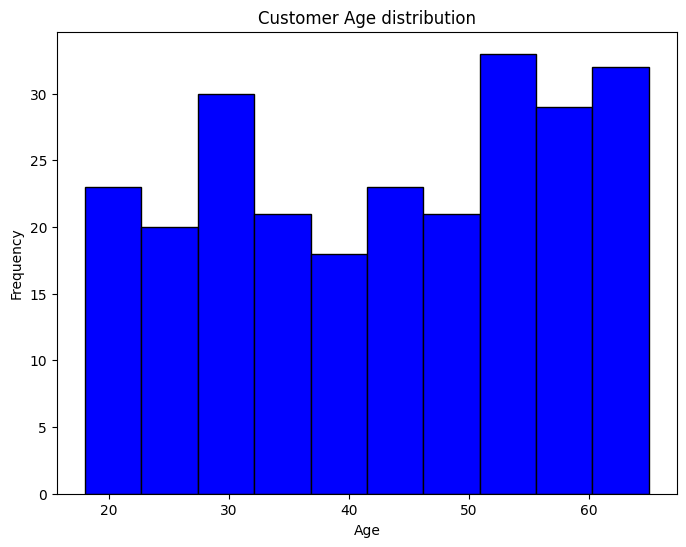

In [14]:
plt.figure(figsize=(8, 6))
plt.hist(df['Age'], bins=10, color="blue",edgecolor="black")
plt.title("Customer Age distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Monthly Income Distribution

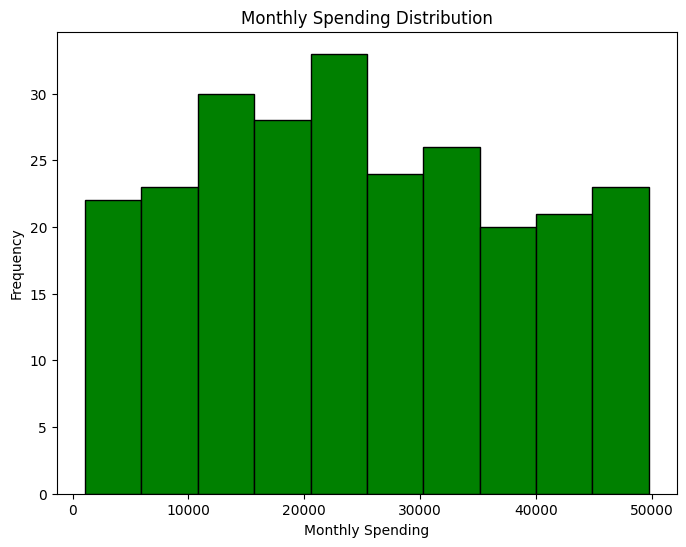

In [15]:
plt.figure(figsize=(8,6))
plt.hist(df["Monthly Spending"],bins=10,color="green",edgecolor="black")
plt.title("Monthly Spending Distribution")
plt.xlabel("Monthly Spending")
plt.ylabel("Frequency")
plt.show()

purchase frequency Distribution

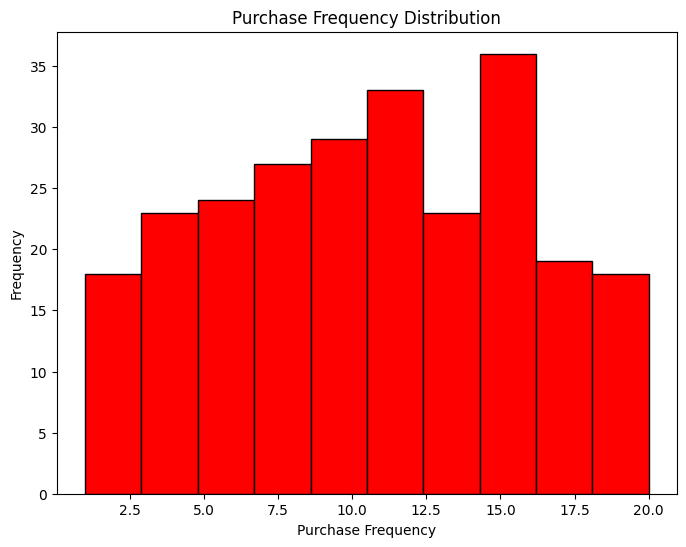

In [16]:
plt.figure(figsize=(8,6))
plt.hist(df["Purchase Frequency"],bins=10,color="red",edgecolor="black")
plt.title("Purchase Frequency Distribution")
plt.xlabel("Purchase Frequency")
plt.ylabel("Frequency")
plt.show()

Customer Rating Distribution

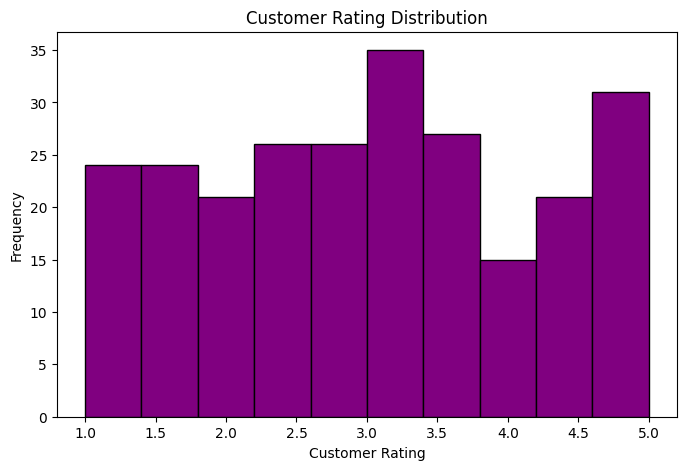

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df["Customer Rating"], bins=10, color='purple', edgecolor='black')
plt.title("Customer Rating Distribution")
plt.xlabel("Customer Rating")
plt.ylabel("Frequency")
plt.show()

Feature Selection

In [18]:
X = df[['Monthly Spending', 'Customer Rating']]
X = X.dropna()
print(X.head())

   Monthly Spending  Customer Rating
0           32398.0              4.2
1           25316.0              1.3
2           41362.0              4.8
3           11145.0              4.2
4           27302.0              1.7


Scatter Plot

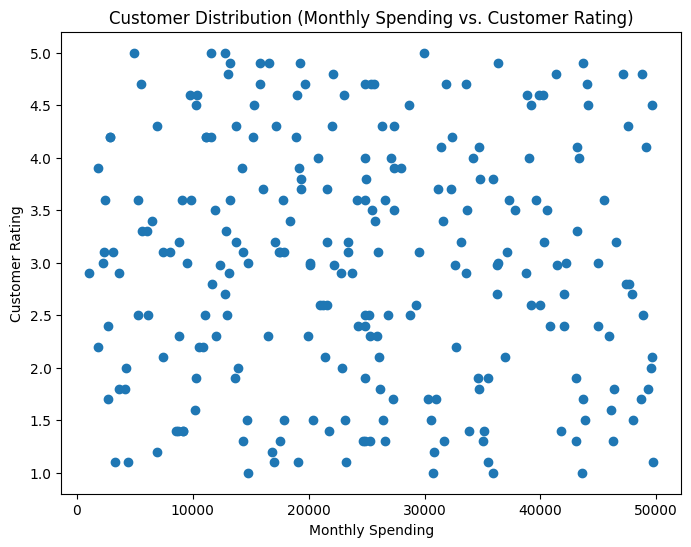

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Monthly Spending"],
    df["Customer Rating"]
)

plt.xlabel("Monthly Spending")

plt.ylabel("Customer Rating")

plt.title("Customer Distribution (Monthly Spending vs. Customer Rating)")

plt.show()

Elbow Method(Plot Elbow Curve)

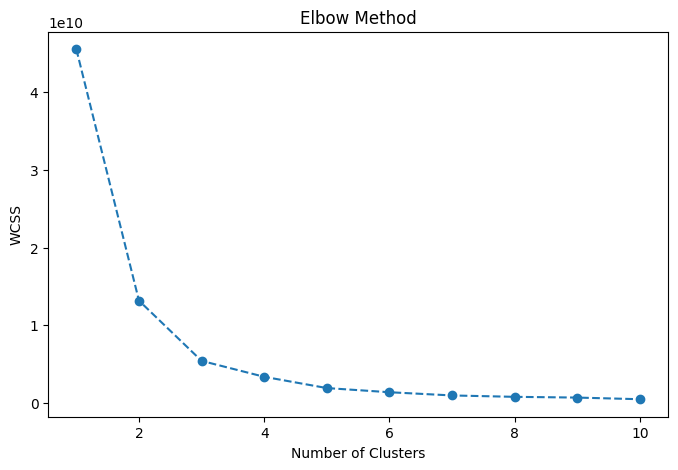

In [20]:
wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init='auto'
    )

    model.fit(X)

    wcss.append(model.inertia_)
plt.figure(figsize=(8,5))

plt.plot(
range(1,11),
wcss,
marker="o",
linestyle="--"
)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

Train K-Means Model

In [21]:
kmeans = KMeans(
n_clusters=5,
random_state=42
)
y_pred = kmeans.fit_predict(X)
print(y_pred)

[1 3 2 4 3 4 4 3 0 2 0 2 4 0 2 2 1 3 4 2 1 3 1 3 1 3 2 0 0 4 4 1 4 3 2 3 2
 2 0 1 3 3 1 1 3 0 3 2 1 3 4 3 1 2 1 0 2 0 2 1 3 4 3 3 2 0 1 3 2 4 0 1 4 1
 1 4 2 0 3 1 2 4 2 4 4 3 4 3 1 1 3 4 3 0 2 4 3 4 4 4 3 0 1 3 2 4 4 2 1 2 2
 4 4 1 4 3 0 1 4 3 2 3 3 3 2 2 4 3 3 1 2 4 4 3 1 0 0 1 2 0 3 1 1 0 4 2 2 3
 3 3 3 4 0 4 2 3 2 0 3 3 0 0 3 3 4 4 1 4 0 2 0 4 1 1 3 3 3 1 1 0 3 0 4 0 1
 0 4 1 2 2 4 1 1 0 0 4 4 3 2 4 4 0 0 3 0 2 4 4 1 4 3 3 3 0 2 3 2 2 1 2 4 1
 0 4 1 2 2 4 3 2 4 1 3 0 1 0 4 3 3 2 3 3 2 1 3 3 1 3 3 3]


Add Cluster Column

In [22]:
df.loc[X.index, "Cluster"] = y_pred
df.head()

,CustomerID,Age,Gender,Product Category,City,Monthly Spending,Purchase Frequency,Payment Method,Customer Rating,Returns,Cluster
0,1,28,Female,Furniture,Hyderabad,32398.0,7,Net Banking,4.2,4,1.0
1,2,29,Male,Electronics,Chennai,25316.0,19,Net Banking,1.3,1,3.0
2,3,32,Male,Furniture,Mumbai,41362.0,15,Cash,4.8,4,2.0
3,4,49,Male,Groceries,Chennai,11145.0,3,Cash,4.2,0,4.0
4,5,47,Male,Sports,Hyderabad,27302.0,16,Card,1.7,0,3.0


Visualize Customer Clusters

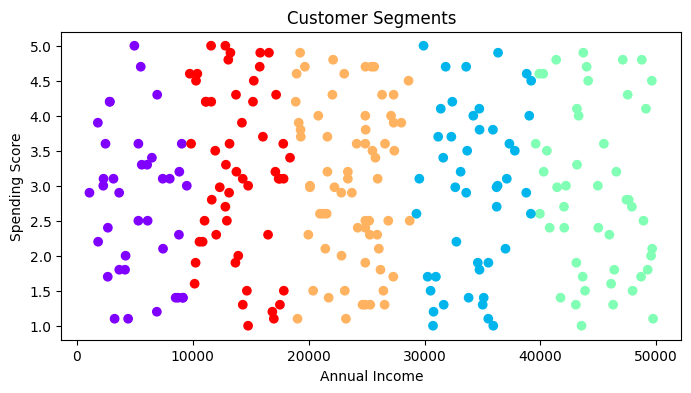

In [23]:
plt.figure(figsize=(8,4))

plt.scatter(
X.iloc[:,0],
X.iloc[:,1],
c=y_pred,
cmap="rainbow"
)

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.title("Customer Segments")

plt.show()

Display Centroids

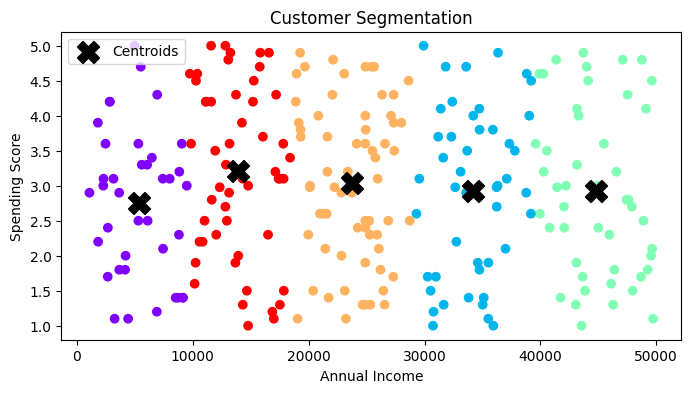

In [24]:
plt.figure(figsize=(8,4))

plt.scatter(
X.iloc[:,0],
X.iloc[:,1],
c=y_pred,
cmap="rainbow"
)
plt.scatter(
kmeans.cluster_centers_[:,0],
kmeans.cluster_centers_[:,1],
s=250,
color="black",
marker="X",
label="Centroids"
)

plt.legend()

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.title("Customer Segmentation")

plt.show()

Cluster Analysis

In [25]:
df.groupby("Cluster").mean(numeric_only=True)


,CustomerID,Age,Monthly Spending,Purchase Frequency,Customer Rating,Returns
Cluster,,,,,,
0.0,131.236842,40.500000,5340.552632,11.052632,2.757895,2.868421
1.0,121.826087,42.173913,34193.695652,10.586957,2.920788,2.521739
2.0,118.553191,42.127660,44813.914894,11.276596,2.922939,2.659574
3.0,130.409091,44.924242,23729.119200,9.803030,3.044792,2.121212
4.0,124.622642,44.886792,13893.547170,10.622642,3.205248,2.320755


In [26]:
df["Cluster"].value_counts()

,count
Cluster,
3.0,66
4.0,53
2.0,47
1.0,46
0.0,38


In [27]:
df[df["Cluster"]==0]

,CustomerID,Age,Gender,Product Category,City,Monthly Spending,Purchase Frequency,Payment Method,Customer Rating,Returns,Cluster
8,9,63,Female,Electronics,Mumbai,5595.0,18,Card,3.3,2,0.0
10,11,37,Male,Electronics,Bengaluru,5302.0,6,Net Banking,2.5,5,0.0
13,14,65,Female,Electronics,Hyderabad,4419.0,9,UPI,1.1,1,0.0
27,28,22,Female,Sports,Pune,2296.0,15,Net Banking,3.1,3,0.0
28,29,43,Male,Clothing,Chennai,4199.0,14,Cash,2.0,5,0.0
38,39,35,Male,Clothing,Bengaluru,3252.0,12,UPI,1.1,4,0.0
45,46,22,Male,Clothing,Pune,7432.0,7,UPI,2.1,0,0.0
55,56,52,Female,Sports,Hyderabad,9050.0,6,Card,3.6,4,0.0
57,58,32,Female,Furniture,Hyderabad,3654.0,18,Net Banking,1.8,2,0.0
65,66,36,Male,Groceries,Mumbai,4960.0,4,Cash,5.0,1,0.0


In [28]:
df[df["Cluster"]==1]

,CustomerID,Age,Gender,Product Category,City,Monthly Spending,Purchase Frequency,Payment Method,Customer Rating,Returns,Cluster
0,1,28,Female,Furniture,Hyderabad,32398.0,7,Net Banking,4.200000,4,1.0
16,17,27,Female,Sports,Mumbai,32749.0,19,Net Banking,2.200000,4,1.0
20,21,59,Female,Clothing,Hyderabad,36301.0,11,Net Banking,3.000000,1,1.0
22,23,65,Male,Electronics,Mumbai,31400.0,3,Net Banking,4.100000,1,1.0
24,25,64,Female,Sports,Pune,33116.0,19,Cash,3.200000,0,1.0
31,32,46,Female,Clothing,Mumbai,33681.0,13,UPI,3.500000,4,1.0
39,40,55,Male,Furniture,Pune,29916.0,15,Card,5.000000,4,1.0
42,43,33,Male,Sports,Pune,31653.0,1,Cash,1.300000,5,1.0
43,44,60,Male,Clothing,Chennai,33594.0,17,Net Banking,2.900000,5,1.0
48,49,31,Male,Groceries,Pune,35901.0,6,Cash,3.800000,3,1.0


In [29]:
df[df["Cluster"]==2]

,CustomerID,Age,Gender,Product Category,City,Monthly Spending,Purchase Frequency,Payment Method,Customer Rating,Returns,Cluster
2,3,32,Male,Furniture,Mumbai,41362.0,15,Cash,4.800000,4,2.0
9,10,53,Male,Clothing,Bengaluru,42058.0,12,UPI,2.400000,4,2.0
11,12,20,Male,Furniture,Bengaluru,49618.0,19,Cash,4.500000,3,2.0
14,15,28,Female,Electronics,Hyderabad,43299.0,5,Card,4.000000,3,2.0
15,16,21,Female,Clothing,Chennai,48750.0,16,Cash,4.800000,2,2.0
19,20,43,Male,Clothing,Chennai,43056.0,15,Card,1.300000,0,2.0
26,27,30,Female,Electronics,Hyderabad,44120.0,14,Cash,4.500000,5,2.0
34,35,24,Male,Furniture,Bengaluru,45477.0,11,UPI,3.600000,5,2.0
36,37,61,Male,Clothing,Pune,46099.0,9,Net Banking,1.600000,3,2.0
37,38,47,Female,Furniture,Mumbai,41441.0,9,Card,2.978125,4,2.0


In [30]:
df[df["Cluster"]==3]

,CustomerID,Age,Gender,Product Category,City,Monthly Spending,Purchase Frequency,Payment Method,Customer Rating,Returns,Cluster
1,2,29,Male,Electronics,Chennai,25316.000000,19,Net Banking,1.3,1,3.0
4,5,47,Male,Sports,Hyderabad,27302.000000,16,Card,1.7,0,3.0
7,8,50,Female,Groceries,Mumbai,26335.000000,9,Cash,4.3,1,3.0
17,18,55,Female,Clothing,Chennai,26058.000000,5,Cash,2.1,2,3.0
21,22,57,Male,Clothing,Bengaluru,25760.000000,7,Cash,3.4,4,3.0
...,...,...,...,...,...,...,...,...,...,...,...
244,245,41,Female,Electronics,Pune,24920.000000,12,UPI,3.8,1,3.0
245,246,51,Male,Groceries,Mumbai,27997.000000,2,Net Banking,3.9,0,3.0
247,248,34,Female,Sports,Mumbai,25416.000000,5,Cash,4.7,0,3.0
248,249,54,Male,Electronics,Mumbai,24888.644531,2,Cash,1.9,5,3.0


In [31]:
df[df["Cluster"]==4]

,CustomerID,Age,Gender,Product Category,City,Monthly Spending,Purchase Frequency,Payment Method,Customer Rating,Returns,Cluster
3,4,49,Male,Groceries,Chennai,11145.0,3,Cash,4.200000,0,4.0
5,6,48,Male,Electronics,Bengaluru,14668.0,19,Cash,1.500000,3,4.0
6,7,53,Female,Clothing,Hyderabad,10578.0,18,Net Banking,2.200000,3,4.0
12,13,50,Female,Clothing,Bengaluru,11636.0,18,Cash,2.800000,3,4.0
18,19,59,Male,Sports,Mumbai,17855.0,13,Card,1.500000,0,4.0
29,30,55,Female,Furniture,Mumbai,16495.0,13,Net Banking,2.300000,1,4.0
30,31,58,Male,Electronics,Mumbai,12327.0,16,UPI,2.978125,1,4.0
32,33,63,Male,Clothing,Hyderabad,14240.0,10,Net Banking,3.900000,0,4.0
50,51,57,Male,Groceries,Mumbai,14772.0,15,UPI,1.000000,2,4.0
61,62,42,Female,Sports,Chennai,17808.0,4,UPI,3.600000,5,4.0


In [32]:
df.to_csv(
"Clustered_Customers.csv",
index=False
)

print("Clustered dataset saved successfully.")

Clustered dataset saved successfully.
